# This Notebook contains a general analysis of all Facebook ads containing a political keyword (PAK)

In [14]:
%load_ext watermark
%watermark -v -n -m -p numpy,scipy,sklearn,pandas
# suppress warnings

import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# reload all modules every time before executing the Python code
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import os
import sys

print(f'default sys.path: {sys.path}')
# Probably not needed for pycharm but needed for vscode -----------------------------------
PROJ_ROOT = os.path.abspath(os.path.join(os.pardir))
PROJ_ROOT = os.path.abspath(os.path.join(PROJ_ROOT, os.pardir))
sys.path.append(PROJ_ROOT)
print(f'Project root: {PROJ_ROOT}')
# Probably not needed for pycharm but needed for vscode -----------------------------------

from utils import mpl_settings
import pandas as pd
from scipy.stats import stats
import pymannkendall as mk
import seaborn as sns
import ast
import numpy as np
from nltk.util import ngrams
from collections import Counter



mpl_settings.apply_settings()

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.10.14
IPython version      : 8.20.0

numpy  : 1.26.4
scipy  : 1.11.4
sklearn: 1.3.0
pandas : 2.2.1

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.1.0-23-amd64
Machine     : x86_64
Processor   : 
CPU cores   : 16
Architecture: 64bit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
default sys.path: ['/home/steph/Documents/code_projects/Political-Advertising-2022-AU-Federal-Election/src/notebooks', '/home/steph/miniconda3/envs/fbads/lib/python310.zip', '/home/steph/miniconda3/envs/fbads/lib/python3.10', '/home/steph/miniconda3/envs/fbads/lib/python3.10/lib-dynload', '', '/home/steph/miniconda3/envs/fbads/lib/python3.10/site-packages', '/home/steph/Documents/code_projects/Political-Advertising-2022-AU-Federal-Election']
Project root: /home/steph/Documents/code_projects/Political-Advertising-2022

In [15]:
from utils.dataset_utilities import load_data

file_path = '../../data/processed/2022_aus_elections_mar_to_may.csv'

df = load_data(file_path)

In [16]:
# columns of the dataset
df.columns

Index(['ad_creation_time', 'ad_creative_body', 'ad_creative_link_caption',
       'ad_creative_link_title', 'ad_delivery_start_time', 'ad_snapshot_url',
       'currency', 'demographic_distribution', 'funding_entity', 'page_id',
       'page_name', 'region_distribution', 'id', 'ad_creative_body_id',
       'mean_spend', 'mean_impressions', 'cost_per_impression', 'languages',
       'impressions.lower_bound', 'impressions.upper_bound',
       'spend.lower_bound', 'spend.upper_bound', 'ad_delivery_stop_time',
       'ad_creative_link_description', 'date_first_detected', 'party', 'state',
       'electorate', 'full_name', 'house_or_senate', 'organization_class',
       'organization_subclass', 'electorate_from_page_name',
       'party_from_page_name', 'state_from_page_name', 'state_from_electorate',
       'custom_body', 'stemmed_body', 'multiword_safe_lemmatized',
       'has_political_keywords', 'has_party', 'macro_party',
       'macro_party_uap'],
      dtype='object')

In [17]:
#df = df[df['has_party'] == True]

In [18]:
total_ads = len(df)
unique_pages = df['page_id'].nunique()
total_impressions = df['mean_impressions'].sum() / 1e6  # in millions
total_spend = df['mean_spend'].sum() /1e6  # in millions
unique_funding_entities = df['funding_entity'].nunique()
cpi = total_spend / total_impressions * 1000
# Print results
print(f"In the two months leading up to the election:")
print(f"Number of ads published: {total_ads}")
print(f"Number of different pages used: {unique_pages}")
print(f"Total impressions generated: {total_impressions:.2f} million")
print(f"Total ad spend: AUD {total_spend:.2f} million")
print(f'Unique funding entities: {unique_funding_entities}')
print(f'Cost per thousand impressions: {cpi:.2f}')


# Optional: You can add these metrics to a dictionary if you want to use them later
election_period_metrics = {
    'total_ads': total_ads,
    'unique_pages': unique_pages,
    'total_impressions_millions': total_impressions,
    'total_spend_aud': total_spend
}

# Print the dictionary
print("\nElection period metrics dictionary:")
print(election_period_metrics)

In the two months leading up to the election:
Number of ads published: 56224
Number of different pages used: 1821
Total impressions generated: 1329.82 million
Total ad spend: AUD 21.53 million
Unique funding entities: 1549
Cost per thousand impressions: 16.19

Election period metrics dictionary:
{'total_ads': 56224, 'unique_pages': 1821, 'total_impressions_millions': 1329.8224525, 'total_spend_aud': 21.530711531950004}


In [19]:
#df = df[df['has_party'] == True]

In [20]:
from utils import config

config.START_DATE - config.END_DATE

Timedelta('-92 days +00:00:00')

In [21]:
from utils.config import ELECTION_DAY
from utils.dataset_utilities import expand_rows_spreading_spend


# Helper function to convert duration to days
def duration_to_days(start, end):
    return (pd.to_datetime(end) - pd.to_datetime(start)).dt.total_seconds() / (24 * 3600)

# Individual ads statistics
def compute_individual_ad_stats(df):
    # Calculate ad duration
    df['ad_duration'] = duration_to_days(df['ad_delivery_start_time'], df['ad_delivery_stop_time'])
    
    # Impressions statistics
    impressions_avg = df['mean_impressions'].mean()
    impressions_median = df['mean_impressions'].median()
    impressions_max = df['mean_impressions'].max()
    
    # Cost statistics
    cost_avg = df['mean_spend'].mean()
    cost_median = df['mean_spend'].median()
    cost_max = df['mean_spend'].max()
    
    # Duration statistics
    duration_avg = df['ad_duration'].mean()
    duration_median = df['ad_duration'].median()
    duration_max = df['ad_duration'].max()
    
    # Efficiency statistics
    df['efficiency'] = df['mean_impressions'] / df['mean_spend']
    efficiency_avg = df['efficiency'].mean()
    efficiency_median = df['efficiency'].median()
    efficiency_max = df['efficiency'].max()
    
    # Language distribution
    language_dist = df['languages'].value_counts()
    english_ads = language_dist.get('en', 0)
    chinese_ads = language_dist.get('zh', 0)
    arabic_ads = language_dist.get('ar', 0)
    total_ads = len(df)
    english_percentage = (english_ads / total_ads) * 100
    chinese_percentage = (chinese_ads / total_ads) * 100
    arabic_percentage = (arabic_ads / total_ads) * 100   
    
    
    return {
        'impressions_avg': impressions_avg,
        'impressions_median': impressions_median,
        'impressions_max': impressions_max,
        'cost_avg': cost_avg,
        'cost_median': cost_median,
        'cost_max': cost_max,
        'duration_avg': duration_avg,
        'duration_median': duration_median,
        'duration_max': duration_max,
        'efficiency_avg': efficiency_avg,
        'efficiency_median': efficiency_median,
        'efficiency_max': efficiency_max,
        'english_ads': english_ads,
        'english_percentage': english_percentage,
        'chinese_ads': chinese_ads,
        'chinese_percentage': chinese_percentage,
        'arabic_ads': arabic_ads,
        'arabic_percentage': arabic_percentage
    }

# Correlation Insights
def compute_correlations(df):
    
    df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['mean_spend', 'mean_impressions', 'ad_duration'])
    def safe_pearsonr(x, y):
        if len(x) > 1:  # Ensure we have at least 2 valid pairs of data points
            return stats.pearsonr(x, y)
        else:
            return (np.nan, np.nan)  # Return NaN if not enough data
    
    # Expense vs Impressions
    corr_expense_impressions, p_expense_impressions = safe_pearsonr(df_clean['mean_spend'], df_clean['mean_impressions'])
    
    # Duration vs Expense
    corr_duration_expense, p_duration_expense = safe_pearsonr(df_clean['ad_duration'], df_clean['mean_spend'])
    
    # Duration vs Impressions
    corr_duration_impressions, p_duration_impressions = safe_pearsonr(df_clean['ad_duration'], df_clean['mean_impressions'])
    
    return {
        'expense_impressions': {
            'correlation': corr_expense_impressions,
            'p_value': p_expense_impressions
        },
        'duration_expense': {
            'correlation': corr_duration_expense,
            'p_value': p_duration_expense
        },
        'duration_impressions': {
            'correlation': corr_duration_impressions,
            'p_value': p_duration_impressions
        }
    }

# Funding Entities Strategies
def compute_funding_entity_stats(df):
    entity_stats = df.groupby('funding_entity').agg({
        'id': 'count',
        'mean_spend': 'sum',
        'mean_impressions': 'sum'
    }).reset_index()
    
    entity_stats['efficiency'] = entity_stats['mean_impressions'] / entity_stats['mean_spend']
    
    return {
        'ads_per_sponsor_avg': entity_stats['id'].mean(),
        'ads_per_sponsor_median': entity_stats['id'].median(),
        'ads_per_sponsor_max': entity_stats['id'].max(),
        'spend_per_sponsor_avg': entity_stats['mean_spend'].mean(),
        'spend_per_sponsor_median': entity_stats['mean_spend'].median(),
        'spend_per_sponsor_max': entity_stats['mean_spend'].max(),
        'impressions_per_sponsor_avg': entity_stats['mean_impressions'].mean(),
        'impressions_per_sponsor_median': entity_stats['mean_impressions'].median(),
        'impressions_per_sponsor_max': entity_stats['mean_impressions'].max(),
        'efficiency_per_sponsor_avg': entity_stats['efficiency'].mean(),
        'efficiency_per_sponsor_median': entity_stats['efficiency'].median()
    }

# Temporal Trends
def compute_temporal_trends(df):
    df = df[df['ad_delivery_stop_time'] <= ELECTION_DAY]
    expanded_df = pd.concat([expand_rows_spreading_spend(row) for index, row in df.iterrows()])
    daily_stats = expanded_df.groupby('date').agg({
        'ad_id': 'count', # it's called ad_id but it contains the count of the ads
        'mean_spend': 'sum',
        'mean_impressions': 'sum'
    }).reset_index()
    
    # Mann-Kendall test for trend in daily ad creation
    mk_result = stats.kendalltau(daily_stats['date'], daily_stats['ad_id']) # test the increasing trend
    
    # Correlation between daily ad creation, expenditure, and views
    corr_creation_expenditure = daily_stats['ad_id'].corr(daily_stats['mean_spend'])
    corr_creation_views = daily_stats['ad_id'].corr(daily_stats['mean_impressions'])
    
    return {
        'mk_statistic': mk_result.correlation,
        'mk_pvalue': mk_result.pvalue,
        'corr_creation_expenditure': corr_creation_expenditure,
        'corr_creation_views': corr_creation_views
    }

# Run all analyses
individual_stats = compute_individual_ad_stats(df)
correlation_insights = compute_correlations(df)
funding_entity_stats = compute_funding_entity_stats(df)
temporal_trends = compute_temporal_trends(df)

# Print results
print("Individual Ad Statistics:")
print(individual_stats)
print("\nCorrelation Insights:")
print(correlation_insights)
print("\nFunding Entity Statistics:")
print(funding_entity_stats)
print("\nTemporal Trends:")
print(temporal_trends)

Individual Ad Statistics:
{'impressions_avg': 23652.22062642288, 'impressions_median': 4499.5, 'impressions_max': 1000000.0, 'cost_avg': 382.94521079876927, 'cost_median': 49.5, 'cost_max': 229624.165, 'duration_avg': 8.419607285145133, 'duration_median': 6.0, 'duration_max': 89.0, 'efficiency_avg': 68.75528033299898, 'efficiency_median': 50.05450500556174, 'efficiency_max': 13290.802764486976, 'english_ads': 54976, 'english_percentage': 97.78030734206034, 'chinese_ads': 384, 'chinese_percentage': 0.6829823562891292, 'arabic_ads': 155, 'arabic_percentage': 0.27568298235628913}

Correlation Insights:
{'expense_impressions': {'correlation': 0.6428968768061797, 'p_value': 0.0}, 'duration_expense': {'correlation': 0.09601633784251888, 'p_value': 2.9538915732225526e-115}, 'duration_impressions': {'correlation': 0.16981652482714563, 'p_value': 0.0}}

Funding Entity Statistics:
{'ads_per_sponsor_avg': 36.24144609425436, 'ads_per_sponsor_median': 6.0, 'ads_per_sponsor_max': 3359, 'spend_per_sp

mk_statistic 0.92 suggests a very strong increasing trend.

extremely small p-value (much smaller than the common significance levels like 0.05 or 0.01).
It indicates that the trend observed is statistically significant.

In [22]:
#count unique ad_creative_body
unique_ad_creative_body = df['stemmed_body'].nunique()
print(f'Unique ad_creative_body: {unique_ad_creative_body}')
# number of rows in the dataset
df.shape[0]
df['languages'].value_counts()
print(f'percentage of english ads: {df[df["languages"] == "en"].shape[0] / df.shape[0]:.3f}')
print(f'percentage of simplified chinese ads: {df[df["languages"] == "zh"].shape[0] / df.shape[0]:.3f}')
print(f'percentage of arabic ads: {df[df["languages"] == "ar"].shape[0] / df.shape[0]:.3f}')
# number of unique funding entities

# total number of impressions
total_impressions = df['mean_impressions'].sum()
print(f'Total impressions: {total_impressions}')
# total amount spent
total_spent = df['mean_spend'].sum()
print(f'Total spent: {total_spent}')
# avarage cost per thousand impressions


Unique ad_creative_body: 21001
percentage of english ads: 0.978
percentage of simplified chinese ads: 0.007
percentage of arabic ads: 0.003
Total impressions: 1329822452.5
Total spent: 21530711.531950004


# Spend on each Term

In [23]:
# print number of NaNs in mean_spend column
print(f'Number of NaNs in mean_spend: {df["mean_spend"].isna().sum()}')

Number of NaNs in mean_spend: 0


In [24]:
has_keywords_not_party = df['has_political_keywords'] & ~df['has_party']
df['has_keywords_not_party'] = has_keywords_not_party
has_keywords_not_party_df = df[has_keywords_not_party]

has_keyword_and_party = df['has_political_keywords'] & df['has_party']
df['has_keyword_and_party'] = has_keyword_and_party
has_keywords_and_party_df = df[has_keyword_and_party]

combined = has_keywords_not_party | has_keyword_and_party

combined_df = df[combined]


# print size of each dataset
print(f'has_keywords_not_party_df: {has_keywords_not_party_df.shape[0]}')
print(f'has_keywords_and_party_df: {has_keywords_and_party_df.shape[0]}')
print(f'combined_df: {combined_df.shape[0]}')
# print how many times has_keywords_and_party_df is bigger than has_keywords_not_party_df
print(f'has_keywords_and_party_df is {has_keywords_and_party_df.shape[0] / has_keywords_not_party_df.shape[0]:.2f} times bigger than has_keywords_not_party_df')


has_keywords_not_party_df: 19028
has_keywords_and_party_df: 28567
combined_df: 47595
has_keywords_and_party_df is 1.50 times bigger than has_keywords_not_party_df


In [25]:
# total amount spent on has_keywords_not_party_df
total_spent_not_party = has_keywords_not_party_df['mean_spend'].sum()
print(f'Total spent on has_keywords_not_party_df: {total_spent_not_party}')
# total amount spent on has_keywords_and_party_df
total_spent_party = has_keywords_and_party_df['mean_spend'].sum()
print(f'Total spent on has_keywords_and_party_df: {total_spent_party}')
# print how many times total_spent_party is bigger than total_spent_not_party
print(f'Total spent on has_keywords_and_party_df is {total_spent_party / total_spent_not_party:.2f} times bigger than total_spent_not_party')

Total spent on has_keywords_not_party_df: 6789699.839999999
Total spent on has_keywords_and_party_df: 11654066.5
Total spent on has_keywords_and_party_df is 1.72 times bigger than total_spent_not_party


In [26]:
print(f"has_keywords: {df[df['has_political_keywords']].shape[0]}")

has_keywords: 47595


In [27]:
def find_top_n_words(df, column_name, n):
    # Combine all words from the specified column into a single list
    all_words = df[column_name].str.split().explode().tolist()
    
    # Count the frequency of each word
    word_counts = Counter(all_words)
    
    # Get the N most common words
    top_n_words = word_counts.most_common(n)
    
    return top_n_words

# Example usage:
# Assuming your DataFrame is named 'df'
n = 100  # Change this to the number of top words you want
top_words = find_top_n_words(df, 'multiword_safe_lemmatized', n)

# Print the results
print(f"The {n} most used words are:")
for word, count in top_words:
    print(f"{word}: {count}")

The 100 most used words are:
labor: 16780
australia: 16383
government: 16301
vote: 15849
australian: 14697
future: 11844
plan: 10972
community: 10959
make: 10648
need: 10629
scott_morrison: 9967
local: 9602
people: 9558
help: 9484
better: 9172
support: 9026
time: 8959
election: 8914
year: 8666
get: 8647
sign: 8465
liberal: 7836
climate: 7764
family: 6783
u: 6748
job: 6738
today: 6655
party: 6607
new: 6404
care: 6256
candidate: 6084
green: 6009
product: 5860
action: 5780
federal: 5759
cost: 5740
like: 5632
child: 5497
one: 5436
take: 5386
petition: 5157
power: 5027
woman: 5019
energy: 4928
life: 4871
protect: 4554
want: 4549
world: 4532
health: 4471
change: 4464
work: 4433
right: 4431
free: 4400
day: 4315
home: 4303
economy: 4301
independent: 4260
back: 3988
million: 3977
every: 3945
risk: 3896
animal: 3851
know: 3780
may: 3697
business: 3685
join: 3676
description: 3658
living: 3646
say: 3552
real: 3499
demand: 3371
stronger: 3368
see: 3350
many: 3321
let: 3320
national: 3319
find: 330

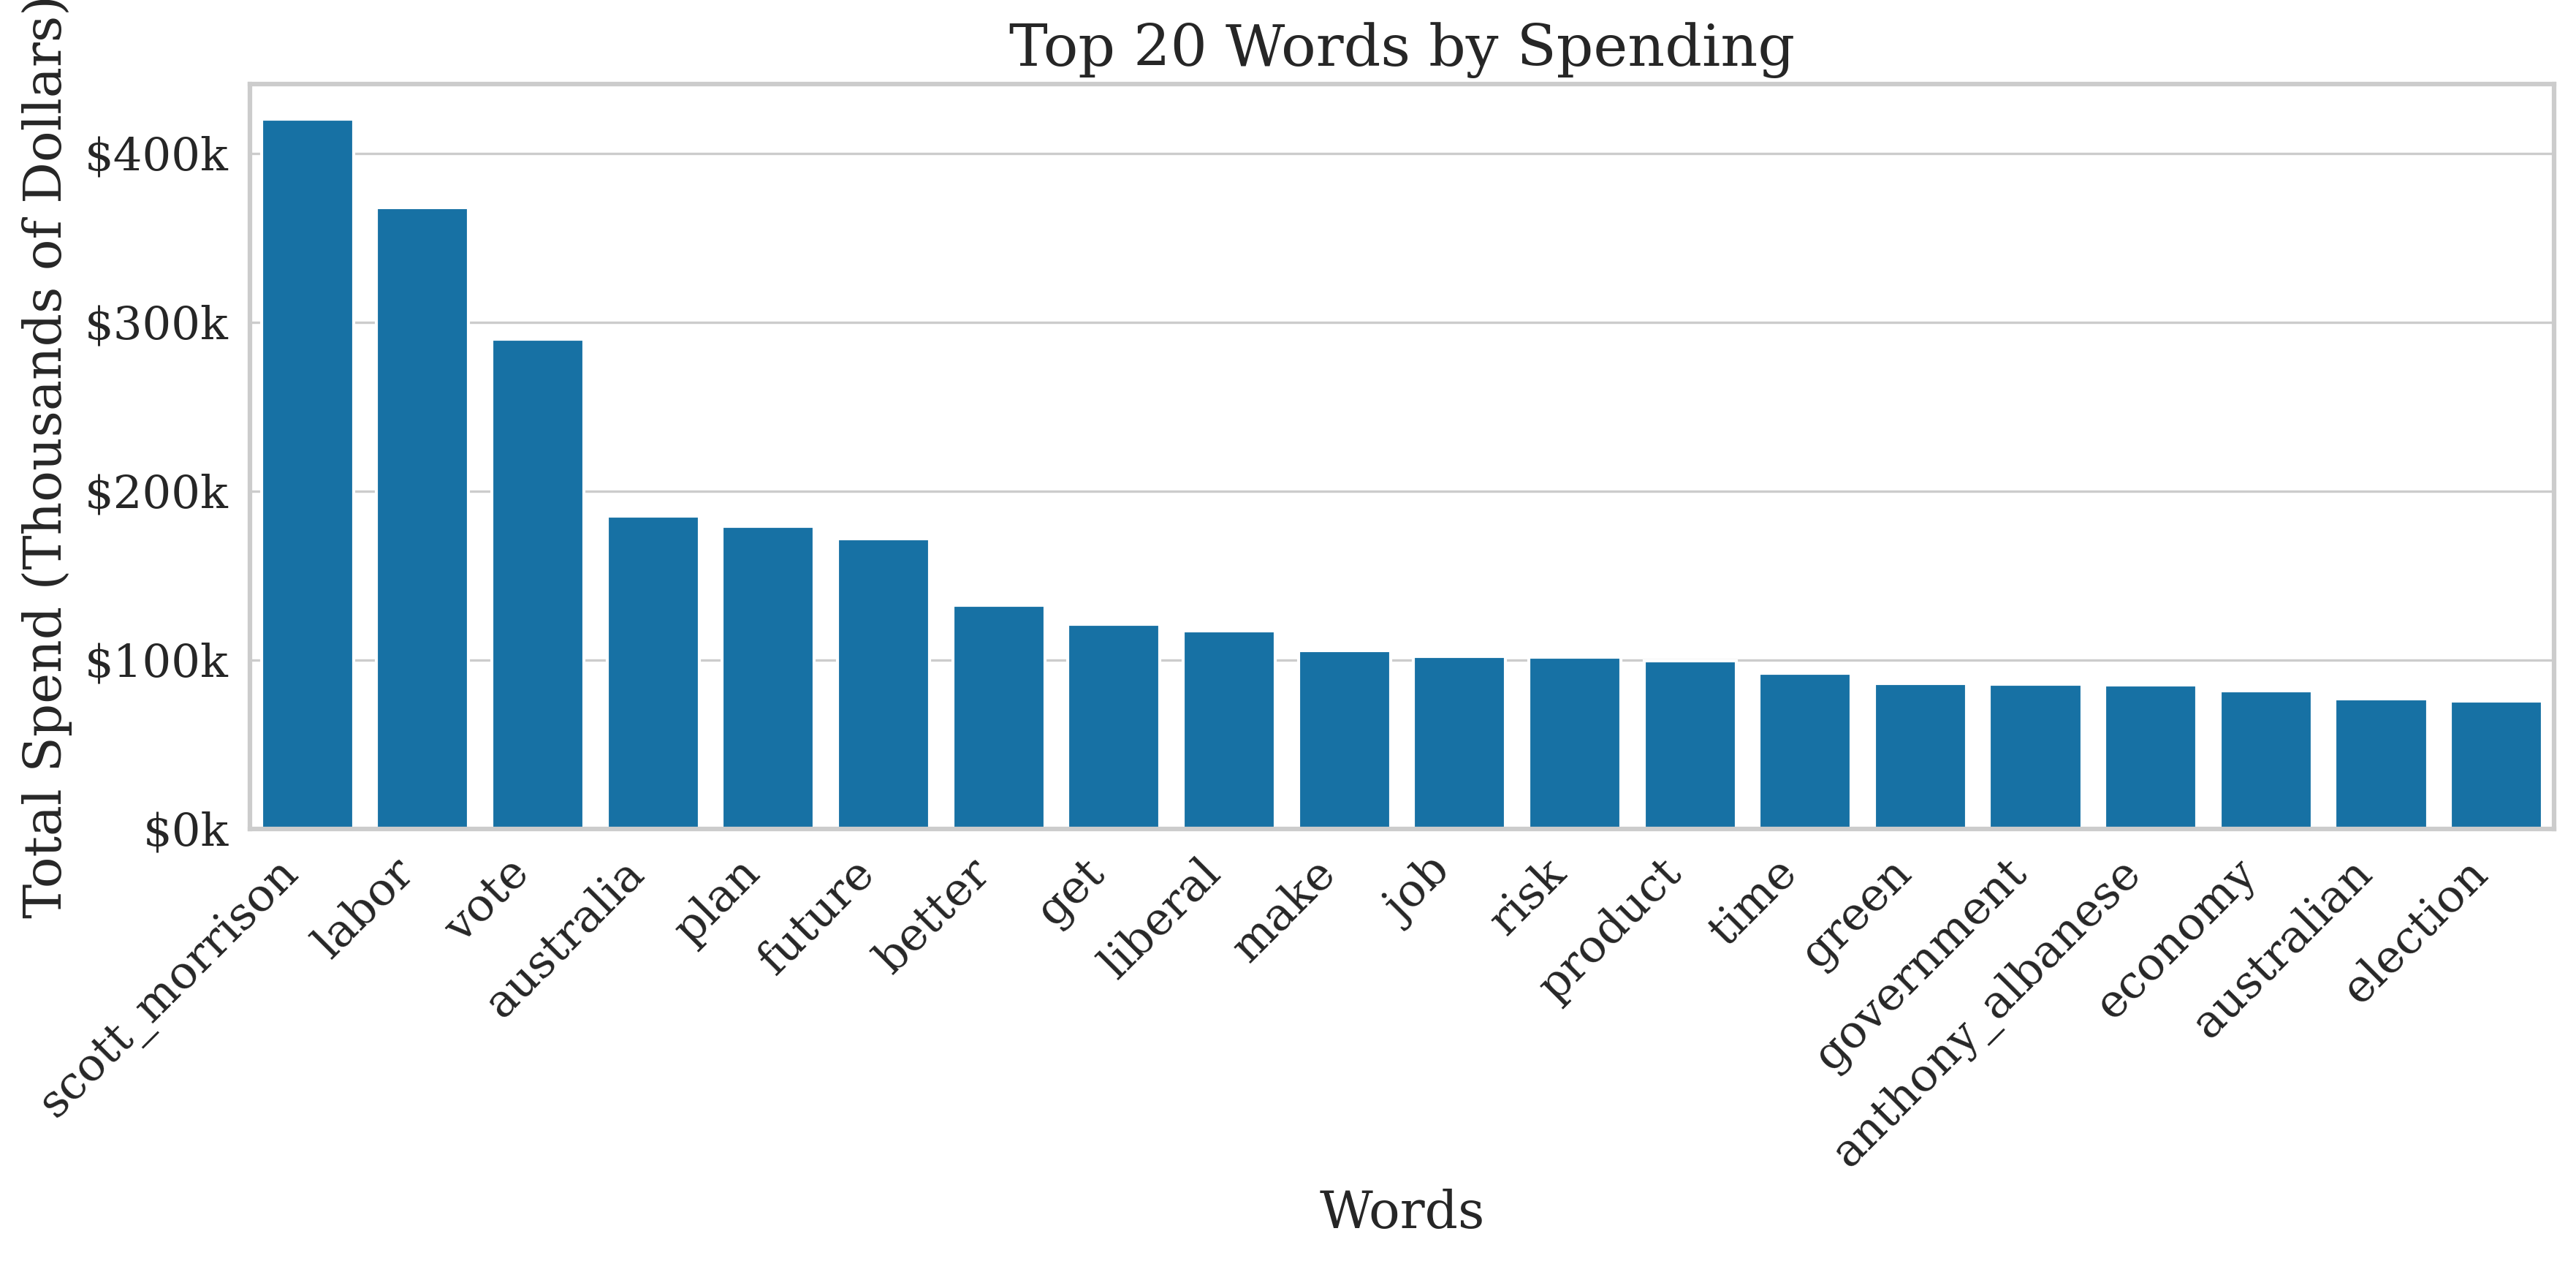

                    total_spend  total_spend_k
scott_morrison    420386.825938     420.386826
labor             367978.180195     367.978180
vote              290403.590101     290.403590
australia         185261.562464     185.261562
plan              179464.098490     179.464098
future            171931.823373     171.931823
better            132529.216465     132.529216
get               121242.827667     121.242828
liberal           117546.287070     117.546287
make              105900.560572     105.900561
job               102511.846181     102.511846
risk              101877.678997     101.877679
product            99727.831352      99.727831
time               92468.510224      92.468510
green              86221.452426      86.221452
government         85827.488333      85.827488
anthony_albanese   85269.394627      85.269395
economy            81912.279811      81.912280
australian         77172.067573      77.172068
election           75879.990761      75.879991


In [28]:
from collections import defaultdict

def plot_spend_on_words(df):
    word_spending = defaultdict(float)
    
    for index, row in df.iterrows():
        words = str(row['multiword_safe_lemmatized']).split()  # Ensure it's a string and split
        spend = row['mean_spend']  # Assuming 'mean_spend' is the column for spending
        for word in words:
            word_spending[word] += spend / len(words)  # Distribute spend equally among words
    
    # Convert to DataFrame and sort
    word_df = pd.DataFrame.from_dict(word_spending, orient='index', columns=['total_spend'])
    word_df = word_df.sort_values('total_spend', ascending=False)
    
    # Select top N words (e.g., top 20)
    N = 20
    top_words = word_df.head(N)
    
    # Create barplot
    plt.figure(figsize=(12, 6))
    
    
    top_words['total_spend_k'] = top_words['total_spend'] / 1000
    
    # Create barplot with the new column
    sns.barplot(x=top_words.index, y='total_spend_k', data=top_words)
    
    # Update y-axis label
    plt.ylabel('Total Spend (Thousands of Dollars)')
    
    # Format y-axis ticks
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}k'))
    plt.title(f'Top {N} Words by Spending')
    plt.xlabel('Words')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print the top words and their spending
    print(top_words)
    
plot_spend_on_words(has_keywords_and_party_df)

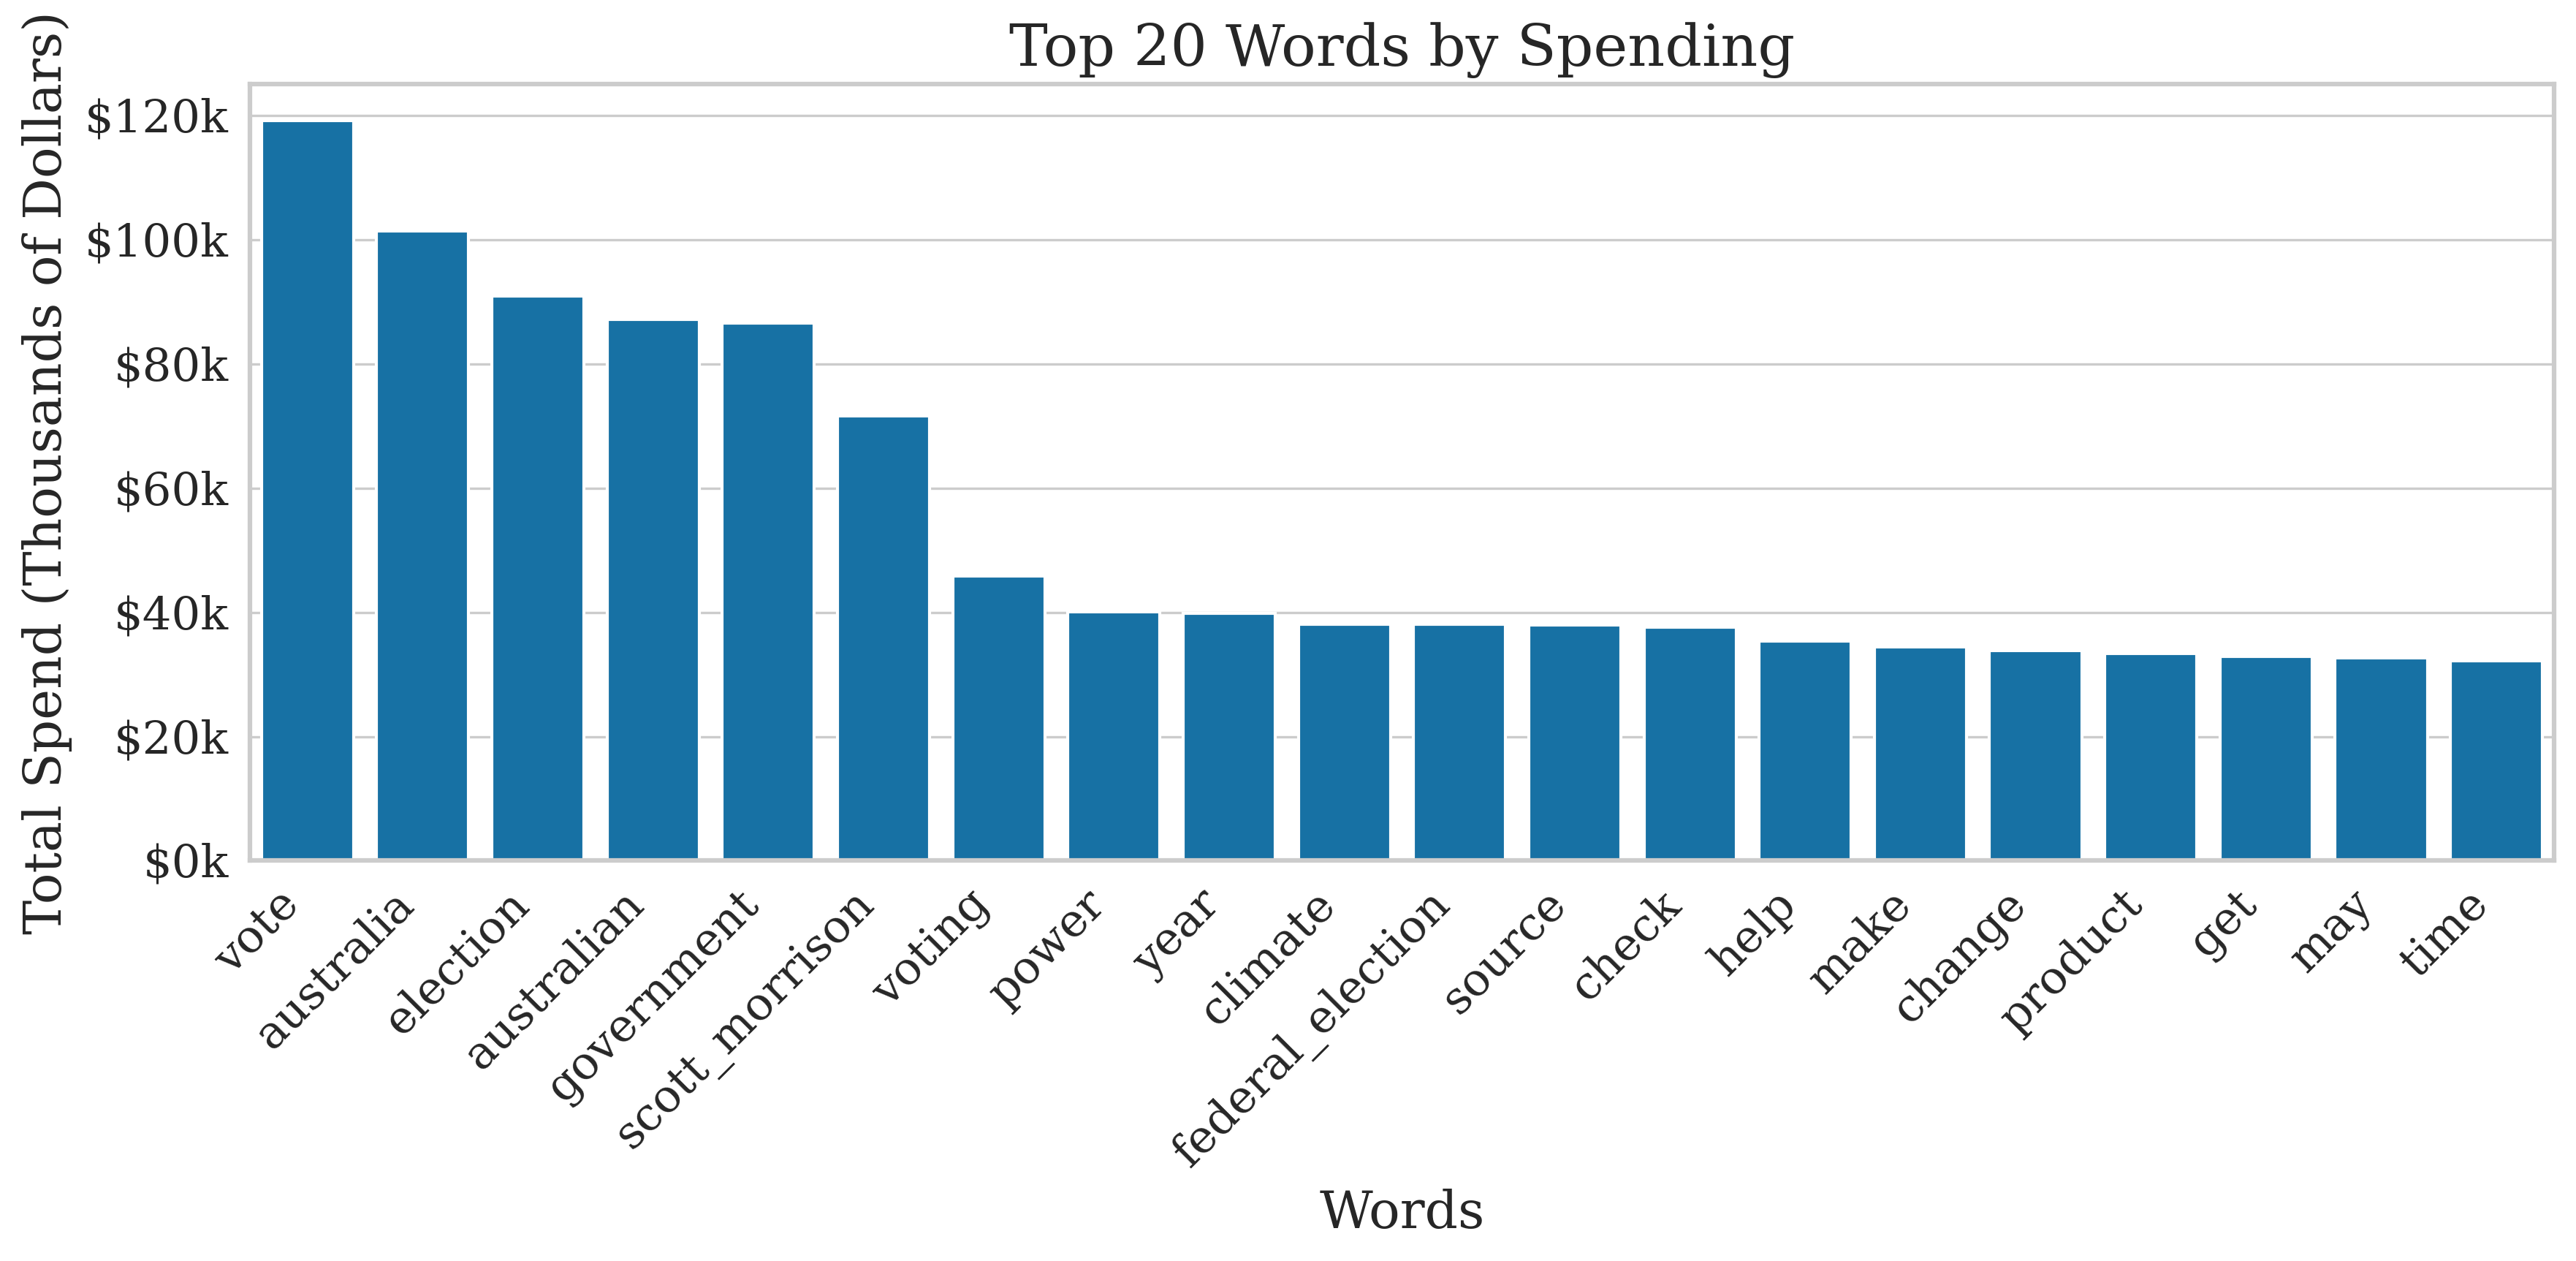

                    total_spend  total_spend_k
vote              119169.250315     119.169250
australia         101469.504678     101.469505
election           90932.117809      90.932118
australian         87221.044019      87.221044
government         86648.245378      86.648245
scott_morrison     71702.195651      71.702196
voting             45807.412579      45.807413
power              40085.922663      40.085923
year               39902.850345      39.902850
climate            38096.750673      38.096751
federal_election   38036.142782      38.036143
source             37924.672596      37.924673
check              37562.690661      37.562691
help               35336.075443      35.336075
make               34445.351447      34.445351
change             33846.629721      33.846630
product            33426.721026      33.426721
get                32945.123721      32.945124
may                32710.832060      32.710832
time               32158.784383      32.158784


In [29]:
plot_spend_on_words(has_keywords_not_party_df)

has_keywords_and_party_df is 1.37 times bigger than has_keywords_not_party_df but the spend is 1.65 times bigger on has_keywords_and_party_df than has_keywords_not_party_df, indicating that parties are willing to spend more per ad. This is also noticeable in the top words by spending, where the top words for has_keywords_and_party_df are more expensive than the top words for has_keywords_not_party_df. Also, the top words are different between the two datasets,

The 30 words with the highest total spend are:
['vote', 'australia', 'labor', 'scott_morrison', 'government', 'australian', 'future', 'plan', 'election', 'make', 'liberal', 'better', 'get', 'need', 'local', 'time', 'job', 'community', 'people', 'year', 'help', 'product', 'climate', 'support', 'right', 'today', 'party', 'green', 'cost', 'new']


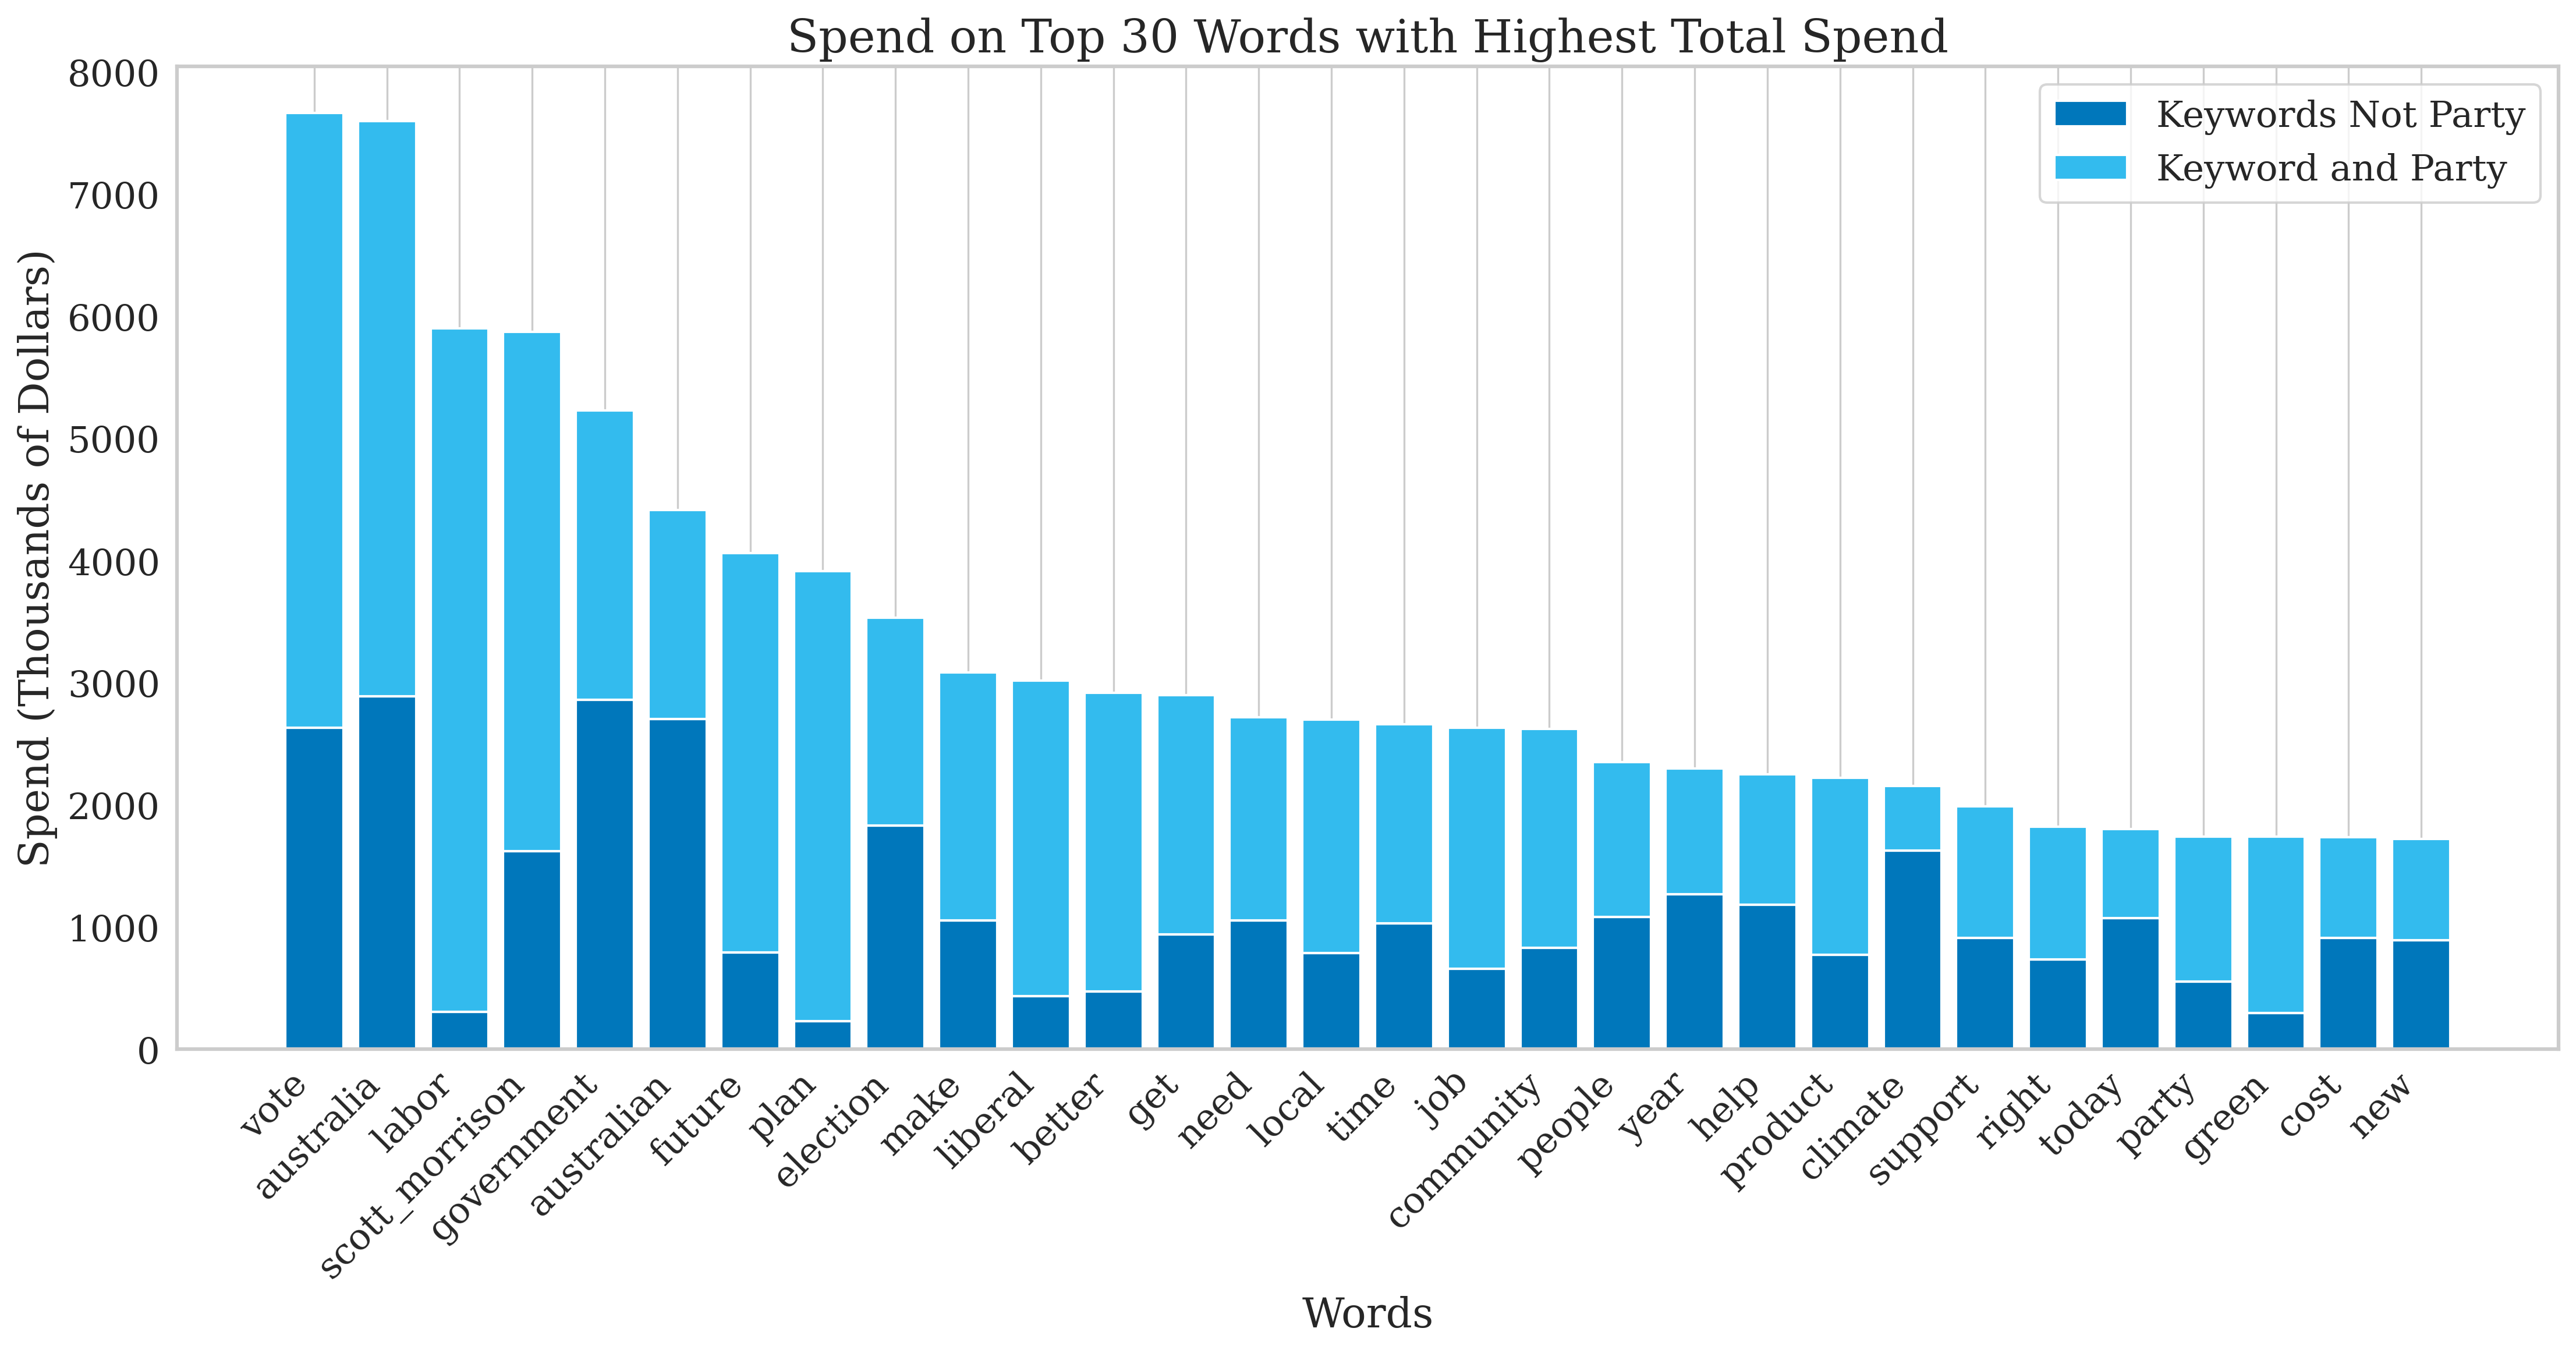

              Word  Keywords Not Party  Keyword and Party       Total
0             vote          2627.31000          5031.6155  7658925.50
1        australia          2884.76250          4706.3910  7591153.50
2            labor           303.27424          5593.2155  5896489.74
3   scott_morrison          1615.76350          4250.5030  5866266.50
4       government          2854.74430          2370.7420  5225486.30
5       australian          2701.34100          1707.7605  4409101.50
6           future           791.16802          3267.6720  4058840.02
7             plan           226.27000          3684.5440  3910814.00
8         election          1828.44250          1700.6505  3529093.00
9             make          1049.87002          2030.9110  3080781.02
10         liberal           430.72800          2581.6040  3012332.00
11          better           468.30264          2445.9855  2914288.14
12             get           935.49028          1960.7180  2896208.28
13            need  

In [30]:
from collections import Counter

def analyze_top_spend_words(df, N=20):
    # Function to calculate total spend for each word in the dataframe
    def calculate_total_word_spend(data):
        word_spend = Counter()
        for _, row in data.iterrows():
            words = str(row['multiword_safe_lemmatized']).split()
            spend = row['mean_spend']
            for word in words:
                word_spend[word] += spend
        return word_spend

    # Calculate total spend for each word
    total_word_spend = calculate_total_word_spend(df)

    # Get the N words with the highest total spend
    top_spend_words = [word for word, _ in total_word_spend.most_common(N)]
    
    print(f"The {N} words with the highest total spend are:")
    print(top_spend_words)

    # Function to calculate spend for each word in a dataframe
    def calculate_word_spend(data):
        word_spend = {word: 0 for word in top_spend_words}
        for _, row in data.iterrows():
            words = str(row['multiword_safe_lemmatized']).split()
            spend = row['mean_spend']
            for word in words:
                if word in word_spend:
                    word_spend[word] += spend
        return word_spend

    # Calculate spend for each category
    keywords_not_party_spend = calculate_word_spend(df[df['has_keywords_not_party']])
    keyword_and_party_spend = calculate_word_spend(df[df['has_keyword_and_party']])

    # Create a dataframe for plotting
    plot_data = pd.DataFrame({
        'Word': top_spend_words,
        'Keywords Not Party': [keywords_not_party_spend[word] for word in top_spend_words],
        'Keyword and Party': [keyword_and_party_spend[word] for word in top_spend_words]
    })

    # Sort by total spend
    plot_data['Total'] = plot_data['Keywords Not Party'] + plot_data['Keyword and Party']
    plot_data = plot_data.sort_values('Total', ascending=False)

    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Convert spend to thousands of dollars for readability
    plot_data['Keywords Not Party'] /= 1000
    plot_data['Keyword and Party'] /= 1000
    
    ax.bar(plot_data['Word'], plot_data['Keywords Not Party'], label='Keywords Not Party')
    ax.bar(plot_data['Word'], plot_data['Keyword and Party'], 
           bottom=plot_data['Keywords Not Party'], label='Keyword and Party')

    ax.set_title(f'Spend on Top {N} Words with Highest Total Spend')
    ax.set_xlabel('Words')
    ax.set_ylabel('Spend (Thousands of Dollars)')
    ax.legend()
    # take out vertical grid lines
    ax.grid(axis='y')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print the data
    print(plot_data)

# Usage
analyze_top_spend_words(combined_df, 30)

The 20 keywords with the highest total spend are:
['vote', 'labor', 'scott_morrison', 'government', 'australian', 'future', 'plan', 'election', 'liberal', 'local', 'community', 'party', 'candidate', 'united_australia_party', 'federal', 'policy', 'anthony_albanese', 'cut', 'nation', 'parliament']


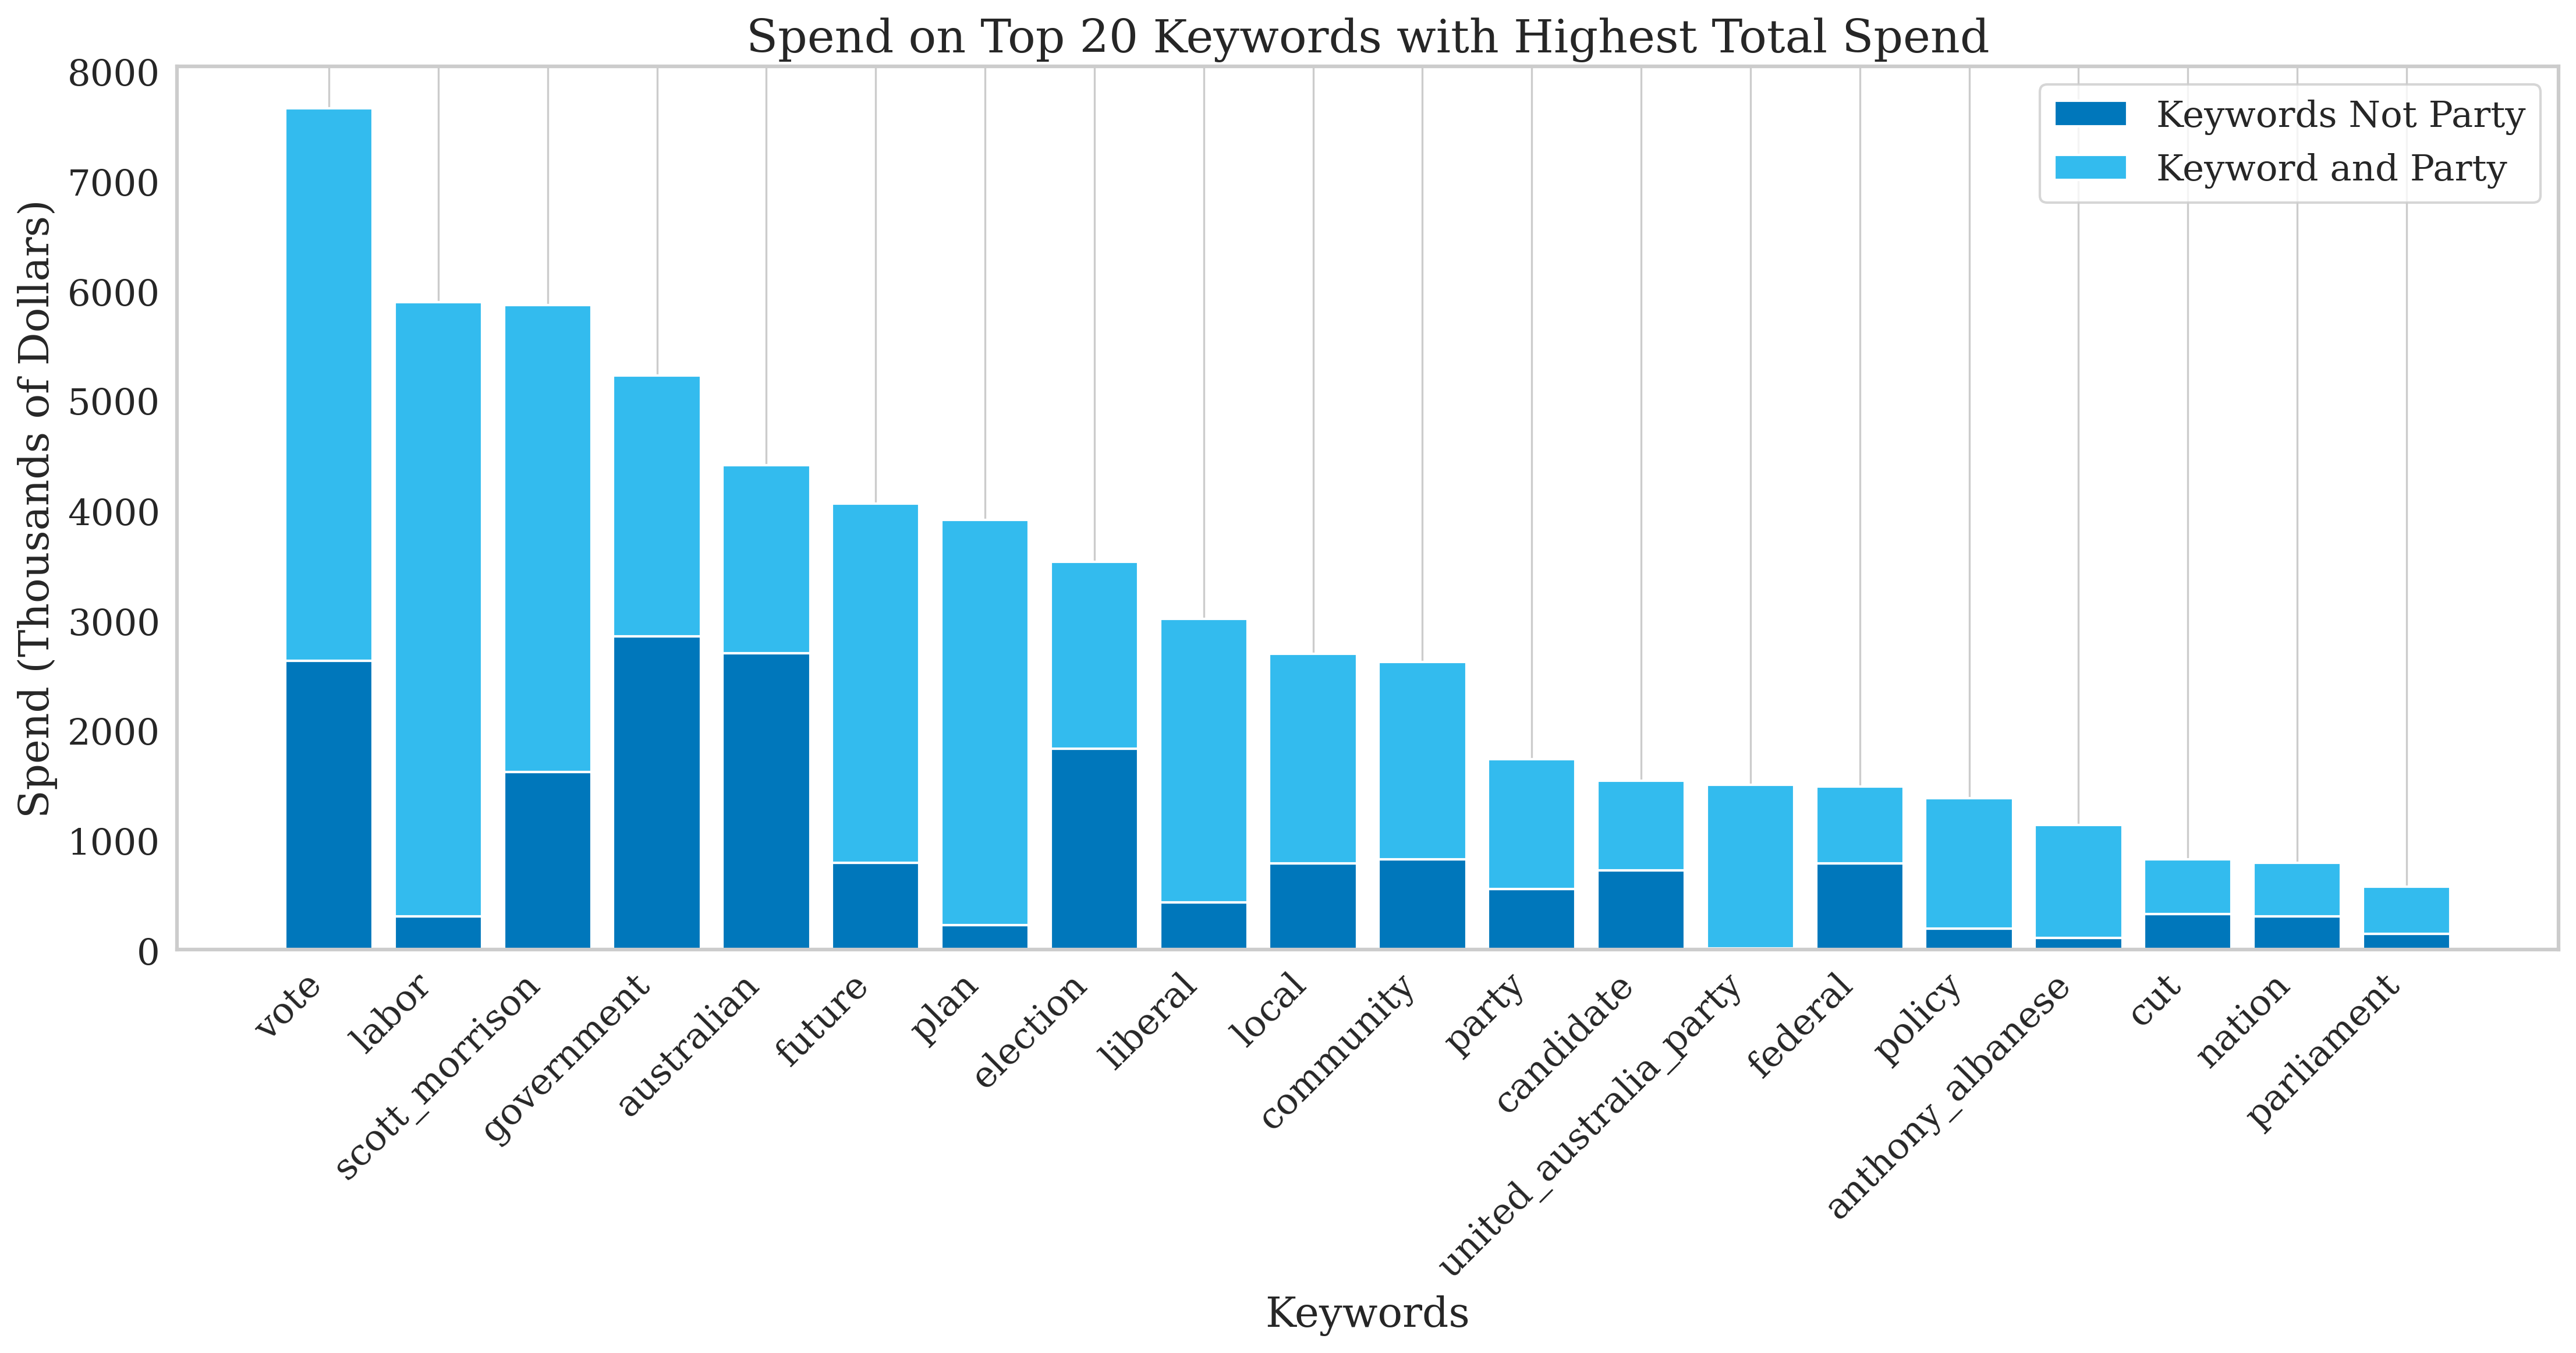

                      Word  Keywords Not Party  Keyword and Party       Total
0                     vote          2627.31000          5031.6155  7658925.50
1                    labor           303.27424          5593.2155  5896489.74
2           scott_morrison          1615.76350          4250.5030  5866266.50
3               government          2854.74430          2370.7420  5225486.30
4               australian          2701.34100          1707.7605  4409101.50
5                   future           791.16802          3267.6720  4058840.02
6                     plan           226.27000          3684.5440  3910814.00
7                 election          1828.44250          1700.6505  3529093.00
8                  liberal           430.72800          2581.6040  3012332.00
9                    local           785.41378          1907.5645  2692978.28
10               community           824.78972          1792.5525  2617342.22
11                   party           551.86000          1184.436

In [31]:
from data.external.keywords import keywords


def analyze_top_spend_words(df, keywords_list, N=20):
    # Function to calculate total spend for each word in the dataframe
    def calculate_total_word_spend(data):
        word_spend = Counter()
        for _, row in data.iterrows():
            words = str(row['multiword_safe_lemmatized']).split()
            spend = row['mean_spend']
            for word in words:
                if word in keywords_list:
                    word_spend[word] += spend
        return word_spend

    # Calculate total spend for each word
    total_word_spend = calculate_total_word_spend(df)

    # Get the N words with the highest total spend
    top_spend_words = [word for word, _ in total_word_spend.most_common(N)]
    
    print(f"The {N} keywords with the highest total spend are:")
    print(top_spend_words)

    # Function to calculate spend for each word in a dataframe
    def calculate_word_spend(data):
        word_spend = {word: 0 for word in top_spend_words}
        for _, row in data.iterrows():
            words = str(row['multiword_safe_lemmatized']).split()
            spend = row['mean_spend']
            for word in words:
                if word in word_spend:
                    word_spend[word] += spend
        return word_spend

    # Calculate spend for each category
    keywords_not_party_spend = calculate_word_spend(df[df['has_keywords_not_party']])
    keyword_and_party_spend = calculate_word_spend(df[df['has_keyword_and_party']])

    # Create a dataframe for plotting
    plot_data = pd.DataFrame({
        'Word': top_spend_words,
        'Keywords Not Party': [keywords_not_party_spend[word] for word in top_spend_words],
        'Keyword and Party': [keyword_and_party_spend[word] for word in top_spend_words]
    })

    # Sort by total spend
    plot_data['Total'] = plot_data['Keywords Not Party'] + plot_data['Keyword and Party']
    plot_data = plot_data.sort_values('Total', ascending=False)

    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Convert spend to thousands of dollars for readability
    plot_data['Keywords Not Party'] /= 1000
    plot_data['Keyword and Party'] /= 1000
    
    ax.bar(plot_data['Word'], plot_data['Keywords Not Party'], label='Keywords Not Party')
    ax.bar(plot_data['Word'], plot_data['Keyword and Party'], 
           bottom=plot_data['Keywords Not Party'], label='Keyword and Party')

    ax.set_title(f'Spend on Top {N} Keywords with Highest Total Spend')
    ax.set_xlabel('Keywords')
    ax.set_ylabel('Spend (Thousands of Dollars)')
    ax.legend()
    ax.grid(axis='y')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print the data
    print(plot_data)

# substitute " " with "_" in keywords
keywords = [keyword.replace(" ", "_") for keyword in keywords]

analyze_top_spend_words(combined_df, keywords, 20)